### 📈 **01. La Régression Linéaire : Prédire des valeurs continues**

Bienvenue dans ce premier notebook ! Nous allons explorer la **Régression Linéaire**, l'un des algorithmes les plus fondamentaux du Machine Learning.

---

#### **Objectif**
L'objectif est de prédire le prix médian des maisons en Californie en fonction de diverses caractéristiques (nombre de pièces, revenu médian, etc.).

#### 📌 **Plan du notebook**
- 📥 Chargement des librairies
- 📊 Présentation du dataset California Housing
- 🔍 Analyse exploratoire et visualisation
- ✂️ Division des données (Train/Test Split)
- 🤖 Entraînement du modèle de Régression Linéaire
- 📏 Évaluation des performances (MSE, R²)
- 💡 Interprétation des résultats

### 📥 **Chargement des librairies**

Nous utilisons `pandas` pour les données, `matplotlib`/`seaborn` pour les graphiques, et `sklearn` pour le Machine Learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   

# pip install virtualenv
# python -m venv venv
# .\venv\Scripts\activate

# Import des outils de Scikit-Learn
from sklearn.datasets import fetch_california_housing  # pip install scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("✅ Librairies chargées !")

✅ Librairies chargées !


### 📊 **Présentation du dataset**

Nous utilisons le dataset **California Housing**.

🔗 Lien Kaggle : [California Housing Prices](https://www.kaggle.com/datasets/camnugent/california-housing-prices)

**Caractéristiques principales :**
- `MedInc` : Revenu médian dans le quartier
- `HouseAge` : Âge médian des maisons
- `AveRooms` : Nombre moyen de pièces
- `Target` (MedHouseVal) : Valeur médiane des maisons (en centaines de milliers de $)

In [16]:
# Chargement du dataset
california = fetch_california_housing()
data = california.data

df = pd.DataFrame(data,  columns=california.feature_names)
df['MedHouseVal'] = california.target  # Ajout de la variable cible au DataFrame

# Affichage des dimensions du dataset
print(f"Dimensions du dataset : {df.shape}")

# Affichage des 5 premières lignes
df.head()


Dimensions du dataset : (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 🔍 **Analyse exploratoire**

Regardons la relation entre le revenu médian (`MedInc`) et le prix des maisons.

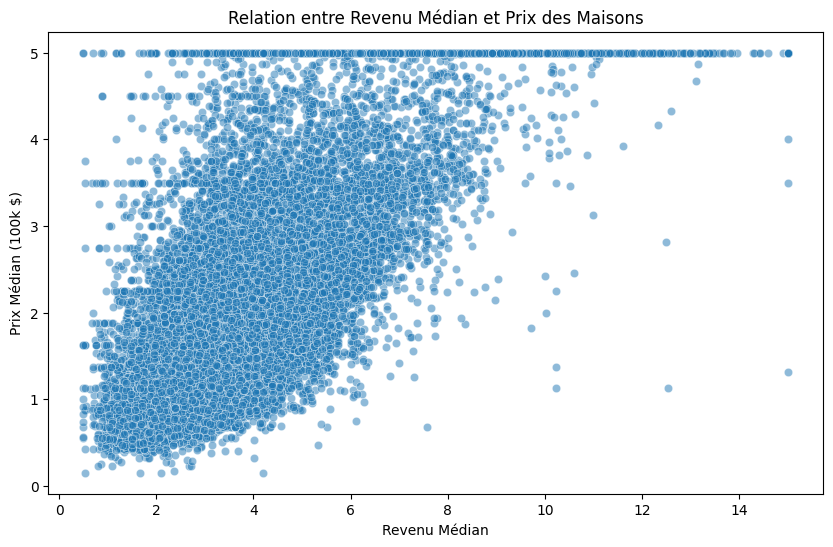

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='MedInc', y='MedHouseVal', alpha=0.5)
plt.title("Relation entre Revenu Médian et Prix des Maisons")
plt.xlabel("Revenu Médian")
plt.ylabel("Prix Médian (100k $)")
plt.show()

### ✂️ **Division des données (Train/Test Split)**

Pour évaluer notre modèle, nous séparons les données en deux :
1. **Train set (80%)** : pour entraîner le modèle.
2. **Test set (20%)** : pour tester si le modèle a bien appris (éviter l'overfitting).

In [ ]:
""" 
1 crochet = 1 dimension (Series)
2 crochets = 2 dimensions (DataFrame)

"""

X = df[['MedInc']]  # On commence avec une seule variable pour simplifier
# Sion , on peut aussi faire : X = df.drop('MedHouseVal', axis=1) pour utiliser toutes les variables sauf la cible 
# # ou encore X = df.iloc[:, :-1] pour prendre toutes les colonnes sauf la dernière
# axis=1 signifie qu'on veut supprimer une colonne (et pas une ligne)
# axis=0 signifie qu'on veut supprimer une ligne (et pas une colonne)

y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille du jeu d'entraînement : {len(X_train)}")
print(f"Taille du jeu de test : {len(X_test)}")


Taille du jeu d'entraînement : 16512
Taille du jeu de test : 4128
<class 'pandas.DataFrame'>


### 🤖 **Entraînement du modèle**

La régression linéaire cherche la meilleure droite qui passe par les points.

In [39]:
model = LinearRegression()
model.fit(X_train, y_train)

print("🚀 Modèle entraîné !")

🚀 Modèle entraîné !


### 📏 **Évaluation des performances**

Nous utilisons deux métriques :
- **MSE (Mean Squared Error)** : L'erreur moyenne au carré (plus c'est bas, mieux c'est).
- **R² (Coefficient de détermination)** : Pourcentage de la variation expliqué par le modèle (proche de 1 = excellent).

In [42]:
# Prédictions
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erreur Quadratique Moyenne (MSE) : {mse:.4f}")
print(f"Score R² : {r2:.4f}")

Erreur Quadratique Moyenne (MSE) : 0.7091
Score R² : 0.4589


### 💡 **Visualisation de la droite de régression**

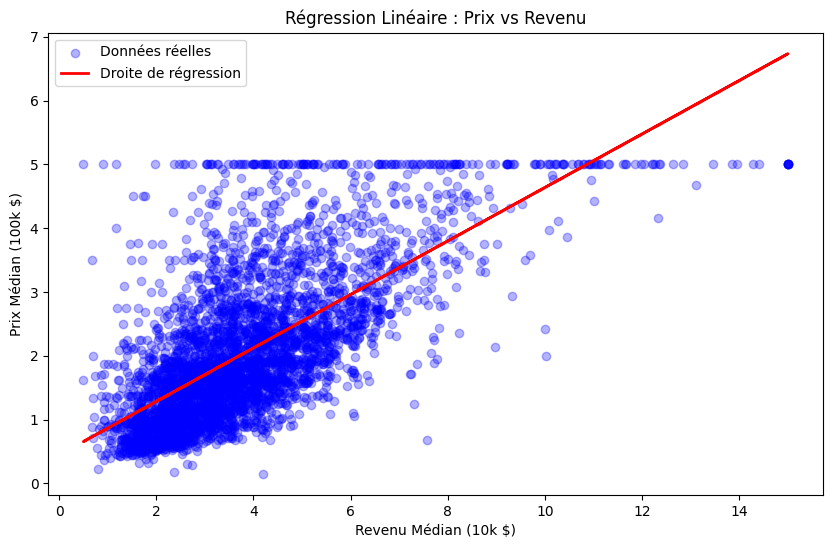

In [45]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', alpha=0.3, label='Données réelles')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Droite de régression')
plt.xlabel("Revenu Médian (10k $)")
plt.ylabel("Prix Médian (100k $)")
plt.title("Régression Linéaire : Prix vs Revenu")
plt.legend()
plt.show()

In [50]:
# Exemple de prédiction pour un revenu médian de 5 (50k $)
exemple_revenu = np.array([[5]])  # 5 correspond à 50k
predicted_price = model.predict(exemple_revenu)
print(f"Prix prédit pour un revenu médian de 50k $ : {predicted_price[0]:.4f} (en centaines de milliers de dollars)")

Prix prédit pour un revenu médian de 50k $ : 2.5413 (en centaines de milliers de dollars)


c:\Users\fofan\Documents\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### ✅ **Conclusion**

- La régression linéaire est idéale pour prédire des **nombres** (prix, température, etc.).
- **Overfitting** : Si le modèle est trop complexe, il apprend par cœur le bruit des données.
- **Underfitting** : Si le modèle est trop simple (comme ici avec une seule variable), il peut manquer de précision.